# Delay-only & Loss-only: baseline vs qaccess_dynamic (PCAP)

Style follows `phase2_qaccess_t_quic_throughput.ipynb` (epoch-aligned all-UDP pcaps, overlay plots).

**Objectives (lower is better):**
- **Delay-only:** minimize delay/jitter proxy + avoid high-delay Path B during 90–100s stress
- **Loss-only:** minimize loss_event / loss_rate proxy + avoid lossy Path B during 90–100s stress

**Throughput is secondary** (shown for side-effect only).

Run: `jupyter notebook scripts/analyze/qaccess_delay_loss_pcap_analysis.ipynb`

## 1. Setup

In [21]:
import importlib.util, json, math, os, shutil, subprocess, sys
from collections import defaultdict
from pathlib import Path

for p in ("pandas", "matplotlib"):
    if importlib.util.find_spec(p) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--disable-pip-version-check", p])

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except (ImportError, AttributeError):
    os.environ.setdefault("MPLBACKEND", "Agg")

from IPython.display import display

def find_repo() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "scripts" / "analyze" / "parse_logs.py").is_file():
            return p
    return cwd

REPO = find_repo()
assert shutil.which("tshark"), "tshark not on PATH — install Wireshark/tshark"
print("REPO =", REPO)

REPO = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment


## 2. Sessions & windows

In [22]:
DELAY_SESSION = REPO / "logs_exp/session_delay_only_20260608_230402"
LOSS_SESSION = REPO / "logs_exp/session_loss_only_20260608_232127"

EXPERIMENTS = {
    "delay": {
        "session": DELAY_SESSION,
        "baseline": "delay_baseline",
        "dynamic": "delay_qaccess_dynamic",
        "objective": "minimize delay / jitter proxy",
    },
    "loss": {
        "session": LOSS_SESSION,
        "baseline": "loss_baseline",
        "dynamic": "loss_qaccess_dynamic",
        "objective": "minimize loss / loss_event",
    },
}

SECOND_MAX = 220
STRESS_MARKS = [(90, "90s delay/loss stress"), (100, "100s recovery")]
PATH_FILTER_ALL = "udp"

WINDOWS = [
    ("0-50 normal", 0, 50),
    ("50-90 pre-stress", 50, 90),
    ("90-100 stress", 90, 100),
    ("100-150 recovery", 100, 150),
    ("150-200 stable", 150, 200),
]

ROLL_SEC = 5  # rolling window for primary time-series plots

for name, cfg in EXPERIMENTS.items():
    print(f"[{name}] {cfg['session']}  objective: {cfg['objective']}")
    for leg in (cfg["baseline"], cfg["dynamic"]):
        rd = cfg["session"] / leg
        pcaps = sorted((rd / "pcaps").glob("path*.pcap")) if (rd / "pcaps").is_dir() else []
        print(f"  {leg}: {len(pcaps)} pcap(s)  samples={ (rd/'qaccess_runtime_samples.csv').is_file() }")

[delay] /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402  objective: minimize delay / jitter proxy
  delay_baseline: 2 pcap(s)  samples=False
  delay_qaccess_dynamic: 2 pcap(s)  samples=True
[loss] /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_loss_only_20260608_232127  objective: minimize loss / loss_event
  loss_baseline: 2 pcap(s)  samples=False
  loss_qaccess_dynamic: 2 pcap(s)  samples=True


## 3. Pcap reader (Fig.7 style)

In [23]:
def find_pcaps(run_dir: Path):
    pcaps = sorted((run_dir / "pcaps").glob("path*.pcap"))
    return next(p for p in pcaps if "pathA" in p.name), next(p for p in pcaps if "pathB" in p.name)


def read_pcap_rows(pcap: Path, display_filter: str = "udp") -> pd.DataFrame:
    cmd = ["tshark", "-r", str(pcap), "-Y", display_filter, "-T", "fields", "-E", "separator=\t",
           "-e", "frame.time_epoch", "-e", "frame.len"]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        raise RuntimeError(proc.stderr[:500])
    rows = []
    for line in proc.stdout.splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2:
            continue
        try:
            rows.append({"epoch": float(parts[0]), "frame_len": int(parts[1])})
        except ValueError:
            pass
    return pd.DataFrame(rows)


def aggregate_mbps(df: pd.DataFrame, global_t0: float, last_second: int) -> pd.Series:
    bins = defaultdict(int)
    for _, row in df.iterrows():
        si = int(math.floor(row["epoch"] - global_t0))
        if 0 <= si <= last_second:
            bins[si] += int(row["frame_len"])
    return pd.Series([bins.get(s, 0) * 8 / 1e6 for s in range(last_second + 1)], dtype="float64")


def load_run_quic_timeseries(run_dir: Path, label: str) -> pd.DataFrame:
    pcap_a, pcap_b = find_pcaps(run_dir)
    print(f"  [{label}] reading {pcap_a.name} + {pcap_b.name} ...", flush=True)
    df_a, df_b = read_pcap_rows(pcap_a), read_pcap_rows(pcap_b)
    epochs = [d["epoch"].min() for d in (df_a, df_b) if not d.empty]
    if not epochs:
        raise RuntimeError(f"no packets in {run_dir}")
    t0 = float(min(epochs))
    last_s = min(SECOND_MAX, max(int(math.floor(d["epoch"].max() - t0)) for d in (df_a, df_b) if not d.empty))
    s_a, s_b = aggregate_mbps(df_a, t0, last_s), aggregate_mbps(df_b, t0, last_s)
    df = pd.DataFrame({"second": range(last_s + 1), "pathA_mbps": s_a.values, "pathB_mbps": s_b.values})
    df["total_mbps"] = df["pathA_mbps"] + df["pathB_mbps"]
    df["pathB_share_pct"] = df["pathB_mbps"] / df["total_mbps"].replace(0, float("nan")) * 100
    return df


def rolling_p95_inter_arrival(pcap: Path, global_t0: float, last_s: int, roll: int = 5) -> pd.Series:
    cmd = ["tshark", "-r", str(pcap), "-Y", "udp", "-T", "fields", "-e", "frame.time_epoch"]
    proc = subprocess.run(cmd, capture_output=True, text=True)
    ts = sorted(float(x) - global_t0 for x in proc.stdout.splitlines() if x.strip())
    if len(ts) < 2:
        return pd.Series(dtype=float)
    ia_by_sec = defaultdict(list)
    for i in range(1, len(ts)):
        if ts[i] > ts[i-1]:
            si = int(math.floor(ts[i]))
            if 0 <= si <= last_s:
                ia_by_sec[si].append((ts[i] - ts[i-1]) * 1000)
    out = []
    for s in range(last_s + 1):
        vals = []
        for k in range(max(0, s - roll + 1), s + 1):
            vals.extend(ia_by_sec.get(k, []))
        out.append(float(pd.Series(vals).quantile(0.95)) if vals else float("nan"))
    return pd.Series(out)


def load_delay_proxy_timeseries(run_dir: Path, label: str) -> pd.DataFrame:
    pcap_a, pcap_b = find_pcaps(run_dir)
    df_a, df_b = read_pcap_rows(pcap_a), read_pcap_rows(pcap_b)
    t0 = float(min(df_a["epoch"].min() if not df_a.empty else 1e18,
                   df_b["epoch"].min() if not df_b.empty else 1e18))
    last_s = min(SECOND_MAX, max(
        int(math.floor(df_a["epoch"].max() - t0)) if not df_a.empty else 0,
        int(math.floor(df_b["epoch"].max() - t0)) if not df_b.empty else 0,
    ))
    ia_a = rolling_p95_inter_arrival(pcap_a, t0, last_s, ROLL_SEC)
    ia_b = rolling_p95_inter_arrival(pcap_b, t0, last_s, ROLL_SEC)
    df = pd.DataFrame({"second": range(last_s + 1)})
    df["p95_ia_pathA_ms"] = ia_a.reindex(range(last_s + 1)).values
    df["p95_ia_pathB_ms"] = ia_b.reindex(range(last_s + 1)).values
    df["p95_ia_combined_ms"] = df[["p95_ia_pathA_ms", "p95_ia_pathB_ms"]].max(axis=1)
    return df


def load_runtime_samples(run_dir: Path) -> pd.DataFrame:
    p = run_dir / "qaccess_runtime_samples.csv"
    if not p.is_file():
        return pd.DataFrame()
    df = pd.read_csv(p)
    if "timestamp_ms" in df.columns:
        t0 = df["timestamp_ms"].min()
        df["second"] = ((df["timestamp_ms"] - t0) / 1000.0).astype(float)
    return df


def loss_event_fraction_by_second(samples: pd.DataFrame, last_s: int, roll: int = 5) -> pd.Series:
    import numpy as np
    if samples.empty:
        return pd.Series([float("nan")] * (last_s + 1))
    any_event = np.zeros(len(samples), dtype=bool)
    for col in ("loss_rate", "retrans_bytes_delta", "lost_bytes_delta"):
        if col in samples.columns:
            any_event |= (pd.to_numeric(samples[col], errors="coerce").fillna(0) > 0).to_numpy()
    if not any_event.any() and not any(c in samples.columns for c in ("loss_rate", "retrans_bytes_delta", "lost_bytes_delta")):
        return pd.Series([float("nan")] * (last_s + 1))
    samples = samples.copy()
    samples["loss_event"] = any_event.astype(float)
    by_sec = samples.groupby(samples["second"].astype(int))["loss_event"].mean()
    out = []
    for s in range(last_s + 1):
        vals = [by_sec.get(k, float("nan")) for k in range(max(0, s - roll + 1), s + 1) if k in by_sec.index]
        vals = [v for v in vals if v == v]
        out.append(float(sum(vals) / len(vals)) if vals else float("nan"))
    return pd.Series(out)

print("Pcap reader ready.")

Pcap reader ready.


## 4. Load all runs

**If loss_event TypeError:** Kernel → Restart, then re-run §1–§4 (old §3 cached in memory).

In [24]:
data = {}
for exp, cfg in EXPERIMENTS.items():
    data[exp] = {"tp": {}, "delay_proxy": {}, "loss_proxy": {}}
    out_dir = cfg["session"] / "compare_csv"
    out_dir.mkdir(parents=True, exist_ok=True)
    data[exp]["out_dir"] = out_dir
    for leg_key, leg_name in (("baseline", cfg["baseline"]), ("dynamic", cfg["dynamic"])):
        rd = cfg["session"] / leg_name
        data[exp]["tp"][leg_key] = load_run_quic_timeseries(rd, leg_name)
        if exp == "delay":
            data[exp]["delay_proxy"][leg_key] = load_delay_proxy_timeseries(rd, leg_name)
        if exp == "loss":
            samp = load_runtime_samples(rd)
            last_s = int(data[exp]["tp"][leg_key]["second"].max())
            frac = loss_event_fraction_by_second(samp, last_s, ROLL_SEC) if not samp.empty else pd.Series([float("nan")] * (last_s + 1))
            data[exp]["loss_proxy"][leg_key] = pd.DataFrame({"second": range(last_s + 1), "loss_event_frac": frac.values})
            if samp.empty:
                print(f"    [note] {leg_name}: no runtime samples — loss_event only for dynamic leg")
        data[exp]["tp"][leg_key].to_csv(out_dir / f"throughput_{leg_key}.csv", index=False)
    print(f"[{exp}] loaded baseline + dynamic")

  [delay_baseline] reading pathA_h1_20260608_230402.pcap + pathB_h1_20260608_230402.pcap ...
  [delay_qaccess_dynamic] reading pathA_h1_20260608_230753.pcap + pathB_h1_20260608_230753.pcap ...
[delay] loaded baseline + dynamic
  [loss_baseline] reading pathA_h1_20260608_232127.pcap + pathB_h1_20260608_232127.pcap ...
    [note] loss_baseline: no runtime samples — loss_event only for dynamic leg
  [loss_qaccess_dynamic] reading pathA_h1_20260608_232518.pcap + pathB_h1_20260608_232518.pcap ...
[loss] loaded baseline + dynamic


## 5. Window summary (primary: lower is better)

In [25]:
def mean_win(series, seconds, lo, hi):
    w = series[(seconds >= lo) & (seconds < hi)]
    return float(w.mean()) if len(w) else float("nan")


def lower_is_better_pct(base, dyn):
    """Positive % means dynamic improved (reduced metric)."""
    if base > 0 and math.isfinite(base) and math.isfinite(dyn):
        return (base - dyn) / base * 100.0
    return float("nan")


summaries = {}
for exp, cfg in EXPERIMENTS.items():
    b_tp, d_tp = data[exp]["tp"]["baseline"], data[exp]["tp"]["dynamic"]
    rows = []
    for wname, lo, hi in WINDOWS + [("0-200 full", 0, min(int(b_tp.second.max()), 200) + 1)]:
        row = {"window": wname}
        if exp == "delay":
            b_d = data[exp]["delay_proxy"]["baseline"]
            d_d = data[exp]["delay_proxy"]["dynamic"]
            b_pri = mean_win(b_d["p95_ia_combined_ms"], b_d["second"], lo, hi)
            d_pri = mean_win(d_d["p95_ia_combined_ms"], d_d["second"], lo, hi)
            row.update(primary_metric="p95_inter_arrival_ms", baseline_primary=round(b_pri, 3),
                         dynamic_primary=round(d_pri, 3),
                         primary_improvement_pct=round(lower_is_better_pct(b_pri, d_pri), 2))
            b_pb = mean_win(b_tp["pathB_share_pct"], b_tp["second"], lo, hi)
            d_pb = mean_win(d_tp["pathB_share_pct"], d_tp["second"], lo, hi)
            row.update(pathB_share_baseline=round(b_pb, 2), pathB_share_dynamic=round(d_pb, 2),
                         pathB_share_reduction_pct=round(lower_is_better_pct(b_pb, d_pb), 2))
        else:
            b_l = data[exp]["loss_proxy"]["baseline"]
            d_l = data[exp]["loss_proxy"]["dynamic"]
            b_pri = mean_win(b_l["loss_event_frac"], b_l["second"], lo, hi)
            d_pri = mean_win(d_l["loss_event_frac"], d_l["second"], lo, hi)
            row.update(primary_metric="loss_event_fraction", baseline_primary=round(b_pri, 4),
                         dynamic_primary=round(d_pri, 4),
                         primary_improvement_pct=round(lower_is_better_pct(b_pri, d_pri), 2))
            b_pb = mean_win(b_tp["pathB_share_pct"], b_tp["second"], lo, hi)
            d_pb = mean_win(d_tp["pathB_share_pct"], d_tp["second"], lo, hi)
            row.update(pathB_share_baseline=round(b_pb, 2), pathB_share_dynamic=round(d_pb, 2),
                         pathB_share_reduction_pct=round(lower_is_better_pct(b_pb, d_pb), 2))
        b_tot = mean_win(b_tp["total_mbps"], b_tp["second"], lo, hi)
        d_tot = mean_win(d_tp["total_mbps"], d_tp["second"], lo, hi)
        row.update(secondary_total_mbps_baseline=round(b_tot, 3), secondary_total_mbps_dynamic=round(d_tot, 3))
        rows.append(row)
    summaries[exp] = pd.DataFrame(rows)
    path = data[exp]["out_dir"] / f"{exp}_primary_window_summary.csv"
    summaries[exp].to_csv(path, index=False)
    print(f"\n=== {exp.upper()} window summary (primary: lower is better) ===")
    display(summaries[exp])
    print("Wrote", path)


=== DELAY window summary (primary: lower is better) ===


,window,primary_metric,baseline_primary,dynamic_primary,primary_improvement_pct,pathB_share_baseline,pathB_share_dynamic,pathB_share_reduction_pct,secondary_total_mbps_baseline,secondary_total_mbps_dynamic
0,0-50 normal,p95_inter_arrival_ms,46.198,56.376,-22.03,10.86,13.28,-22.26,18.925,20.180
1,50-90 pre-stress,p95_inter_arrival_ms,3.361,2.411,28.27,14.09,11.66,17.23,23.613,24.614
2,90-100 stress,p95_inter_arrival_ms,3.382,2.416,28.56,18.08,14.61,19.17,24.879,23.662
3,100-150 recovery,p95_inter_arrival_ms,3.480,2.467,29.12,3.75,19.20,-412.24,22.212,25.010
4,150-200 stable,p95_inter_arrival_ms,3.452,2.397,30.55,1.26,24.52,-1839.16,23.987,26.937
5,0-200 full,p95_inter_arrival_ms,14.071,15.846,-12.61,7.64,17.38,-127.40,22.263,24.156


Wrote /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402/compare_csv/delay_primary_window_summary.csv

=== LOSS window summary (primary: lower is better) ===


,window,primary_metric,baseline_primary,dynamic_primary,primary_improvement_pct,pathB_share_baseline,pathB_share_dynamic,pathB_share_reduction_pct,secondary_total_mbps_baseline,secondary_total_mbps_dynamic
0,0-50 normal,loss_event_fraction,NaN,0.3333,NaN,13.26,9.19,30.67,18.840,19.668
1,50-90 pre-stress,loss_event_fraction,NaN,NaN,NaN,11.61,1.92,83.44,23.281,23.119
2,90-100 stress,loss_event_fraction,NaN,NaN,NaN,13.10,1.86,85.81,23.954,23.674
3,100-150 recovery,loss_event_fraction,NaN,NaN,NaN,3.71,1.80,51.51,22.204,24.463
4,150-200 stable,loss_event_fraction,NaN,NaN,NaN,1.90,1.72,9.51,22.882,26.060
5,0-200 full,loss_event_fraction,NaN,0.3333,NaN,7.67,3.62,52.81,21.843,23.374


Wrote /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_loss_only_20260608_232127/compare_csv/loss_primary_window_summary.csv


## 6. Comparison plots — baseline vs dynamic (overlay)

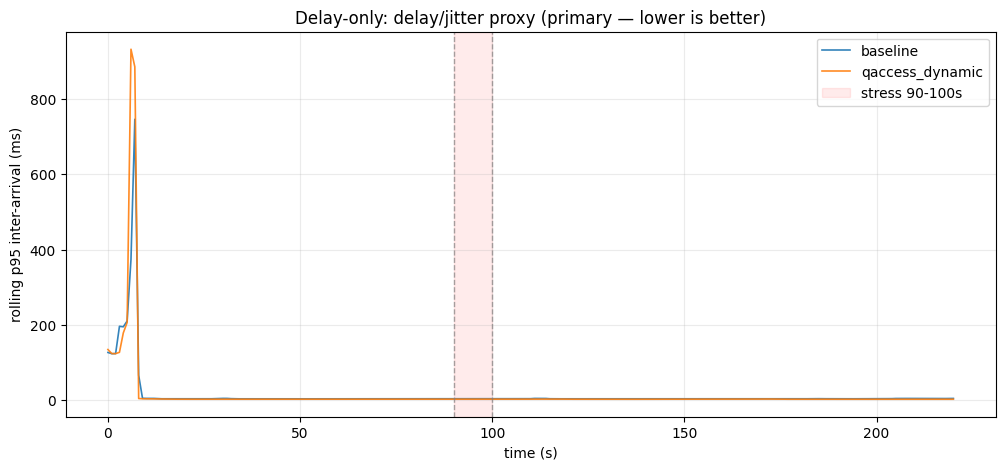

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402/compare_csv/delay_compare_p95_inter_arrival.png


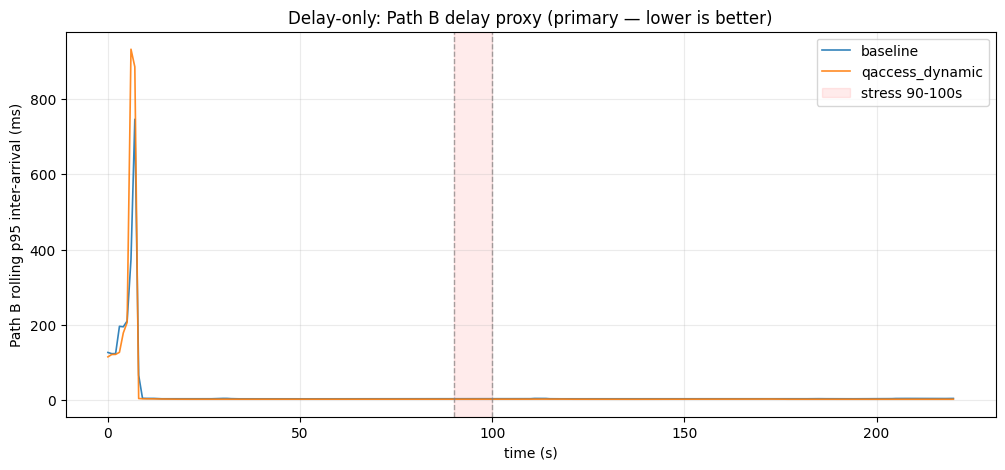

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402/compare_csv/delay_compare_pathB_p95_ia.png


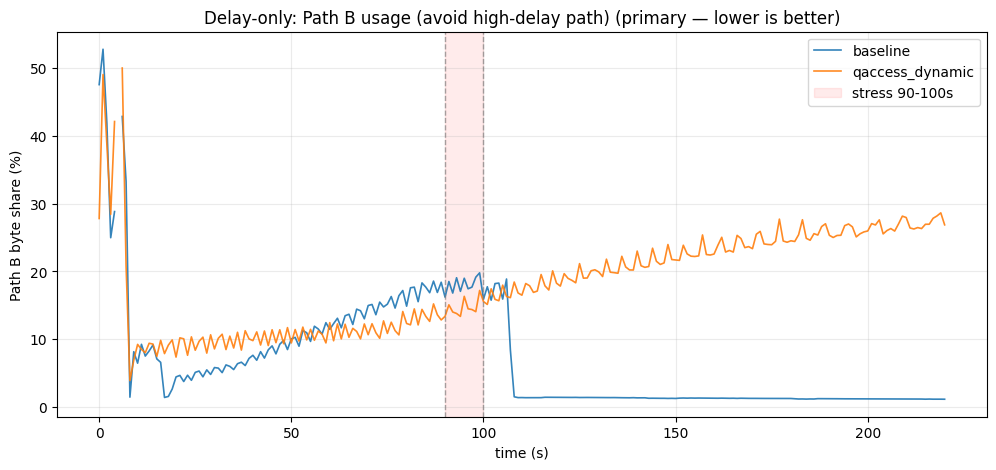

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402/compare_csv/delay_compare_pathB_share.png


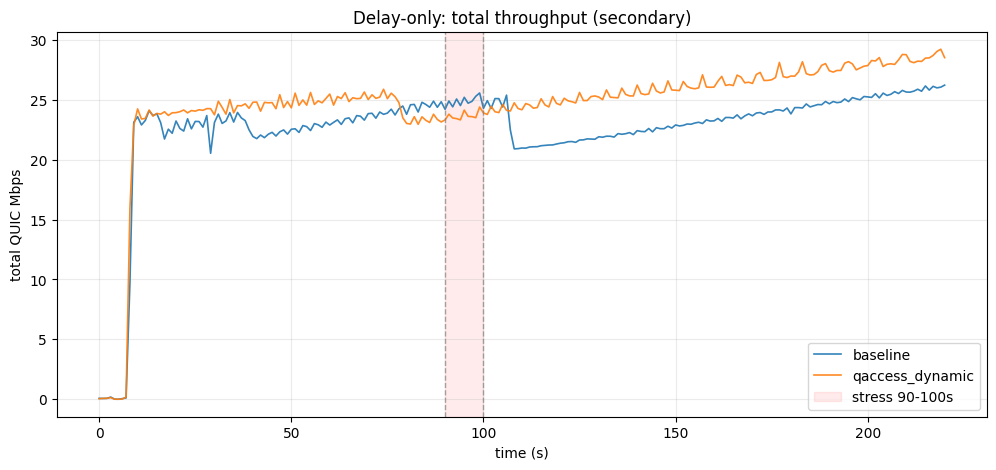

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402/compare_csv/delay_compare_total_throughput_secondary.png


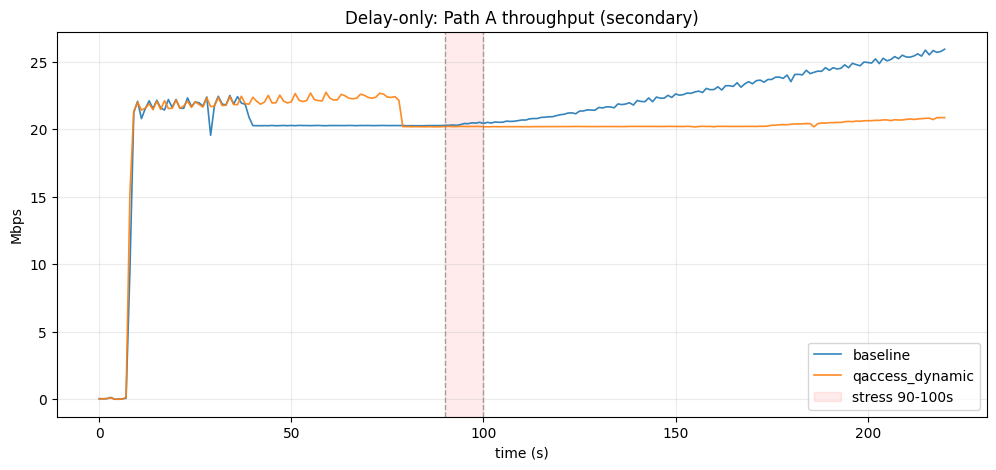

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402/compare_csv/delay_compare_pathA_tp_secondary.png


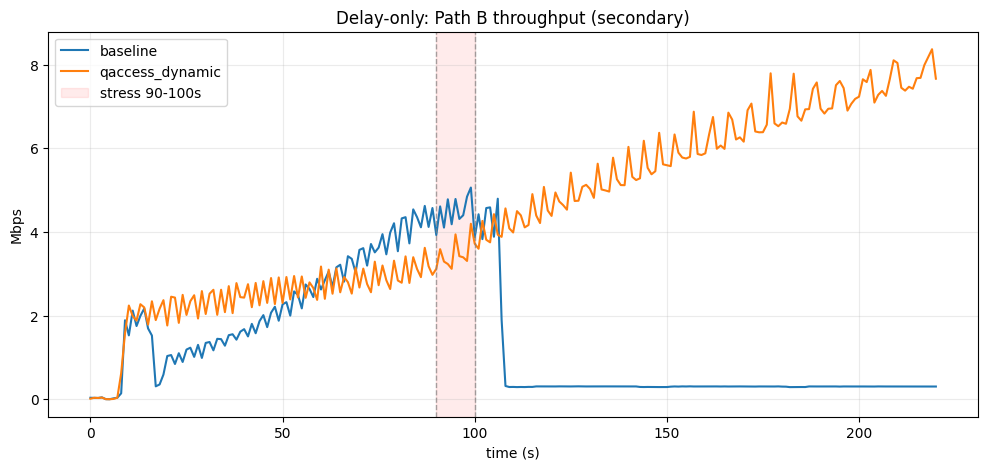

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_delay_only_20260608_230402/compare_csv/delay_compare_pathB_tp_secondary.png


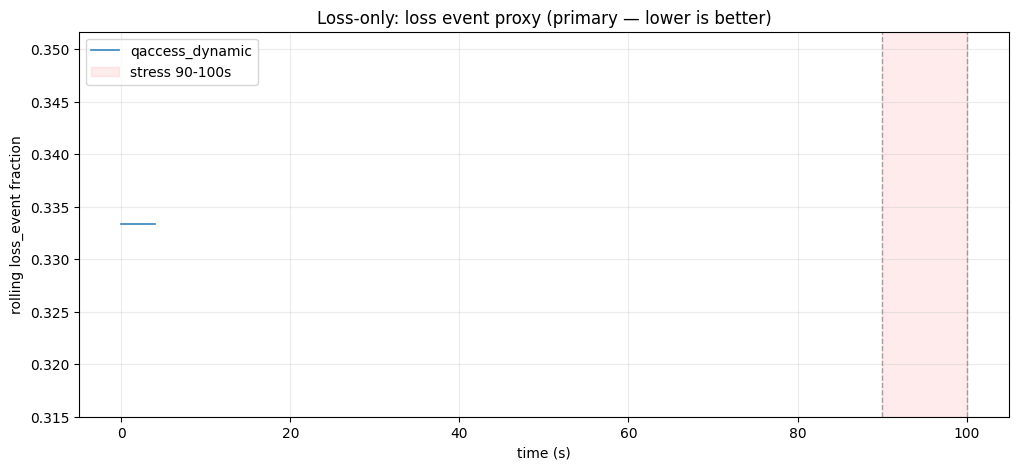

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_loss_only_20260608_232127/compare_csv/loss_compare_loss_event_fraction.png


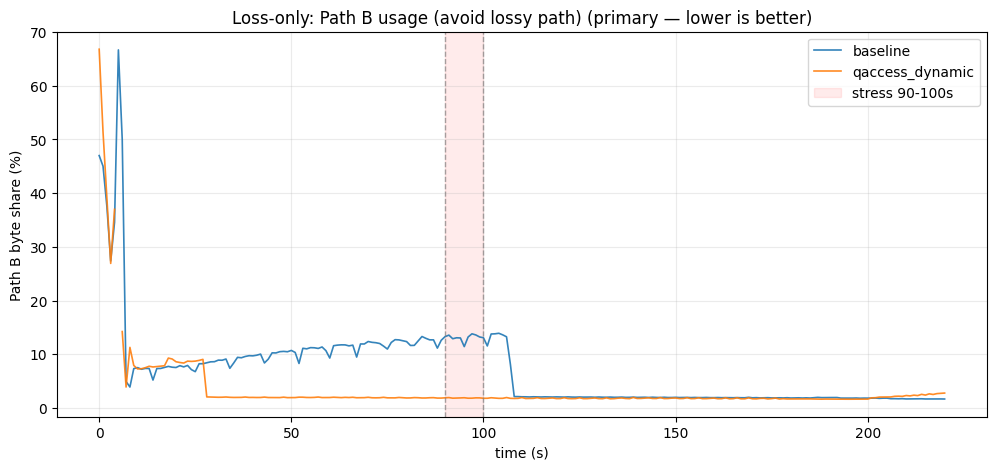

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_loss_only_20260608_232127/compare_csv/loss_compare_pathB_share.png


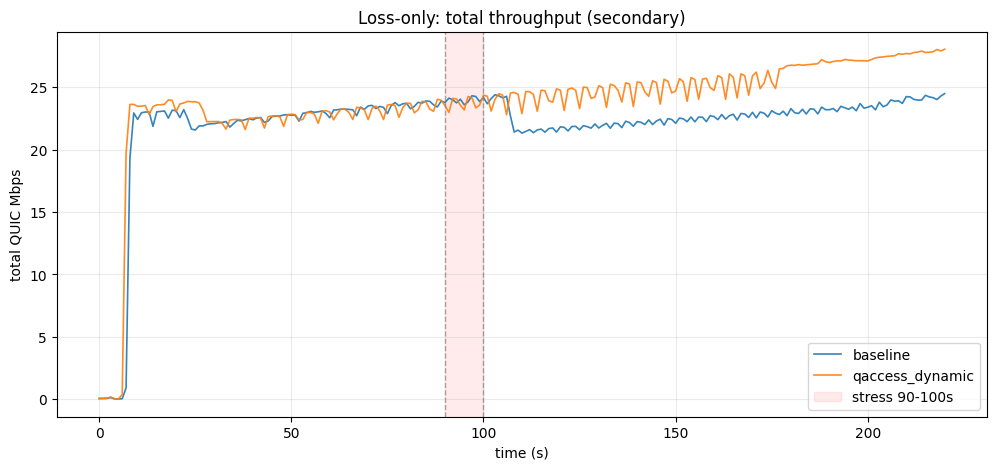

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_loss_only_20260608_232127/compare_csv/loss_compare_total_throughput_secondary.png


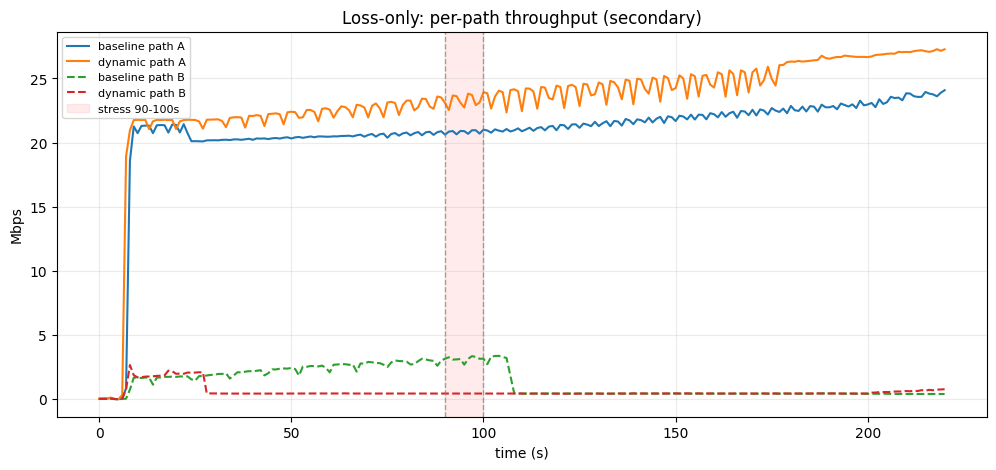

Saved /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/session_loss_only_20260608_232127/compare_csv/loss_compare_per_path_tp_secondary.png


In [26]:
def add_stress_marks(ax):
    for t, lbl in STRESS_MARKS:
        ax.axvline(t, linestyle="--", linewidth=1, color="gray", alpha=0.7)
    ax.axvspan(90, 100, alpha=0.08, color="red", label="stress 90-100s")


def plot_overlay(exp: str, col: str, ylabel: str, title: str, fname: str, *, secondary: bool = False):
    cfg = EXPERIMENTS[exp]
    b, d = data[exp]["tp"]["baseline"], data[exp]["tp"]["dynamic"]
    if exp == "delay" and col.startswith("p95"):
        b, d = data[exp]["delay_proxy"]["baseline"], data[exp]["delay_proxy"]["dynamic"]
    elif exp == "loss" and col == "loss_event_frac":
        b, d = data[exp]["loss_proxy"]["baseline"], data[exp]["loss_proxy"]["dynamic"]
    fig, ax = plt.subplots(figsize=(12, 5))
    if b[col].notna().any():
        ax.plot(b["second"], b[col], label="baseline", linewidth=1.2, alpha=0.9)
    ax.plot(d["second"], d[col], label="qaccess_dynamic", linewidth=1.2, alpha=0.9)
    add_stress_marks(ax)
    tag = "(secondary)" if secondary else "(primary — lower is better)"
    ax.set_title(f"{title} {tag}")
    ax.set_xlabel("time (s)")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    out = data[exp]["out_dir"] / fname
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved", out)


# --- Delay-only: primary delay + path B share; secondary throughput ---
plot_overlay("delay", "p95_ia_combined_ms", "rolling p95 inter-arrival (ms)",
             "Delay-only: delay/jitter proxy", "delay_compare_p95_inter_arrival.png")
plot_overlay("delay", "p95_ia_pathB_ms", "Path B rolling p95 inter-arrival (ms)",
             "Delay-only: Path B delay proxy", "delay_compare_pathB_p95_ia.png")
plot_overlay("delay", "pathB_share_pct", "Path B byte share (%)",
             "Delay-only: Path B usage (avoid high-delay path)", "delay_compare_pathB_share.png")
plot_overlay("delay", "total_mbps", "total QUIC Mbps", "Delay-only: total throughput",
             "delay_compare_total_throughput_secondary.png", secondary=True)
plot_overlay("delay", "pathA_mbps", "Mbps", "Delay-only: Path A throughput",
             "delay_compare_pathA_tp_secondary.png", secondary=True)
# path B tp uses tp dfs
fig, ax = plt.subplots(figsize=(12, 5))
b, d = data["delay"]["tp"]["baseline"], data["delay"]["tp"]["dynamic"]
ax.plot(b["second"], b["pathB_mbps"], label="baseline")
ax.plot(d["second"], d["pathB_mbps"], label="qaccess_dynamic")
add_stress_marks(ax)
ax.set_title("Delay-only: Path B throughput (secondary)")
ax.set_xlabel("time (s)"); ax.set_ylabel("Mbps"); ax.legend(); ax.grid(True, alpha=0.25)
out = data["delay"]["out_dir"] / "delay_compare_pathB_tp_secondary.png"
fig.savefig(out, dpi=200, bbox_inches="tight"); plt.show(); print("Saved", out)

# --- Loss-only: primary loss_event + path B share; secondary throughput ---
plot_overlay("loss", "loss_event_frac", "rolling loss_event fraction",
             "Loss-only: loss event proxy", "loss_compare_loss_event_fraction.png")
plot_overlay("loss", "pathB_share_pct", "Path B byte share (%)",
             "Loss-only: Path B usage (avoid lossy path)", "loss_compare_pathB_share.png")
plot_overlay("loss", "total_mbps", "total QUIC Mbps", "Loss-only: total throughput",
             "loss_compare_total_throughput_secondary.png", secondary=True)
fig, ax = plt.subplots(figsize=(12, 5))
b, d = data["loss"]["tp"]["baseline"], data["loss"]["tp"]["dynamic"]
ax.plot(b["second"], b["pathA_mbps"], label="baseline path A")
ax.plot(d["second"], d["pathA_mbps"], label="dynamic path A")
ax.plot(b["second"], b["pathB_mbps"], label="baseline path B", linestyle="--")
ax.plot(d["second"], d["pathB_mbps"], label="dynamic path B", linestyle="--")
add_stress_marks(ax)
ax.set_title("Loss-only: per-path throughput (secondary)")
ax.set_xlabel("time (s)"); ax.set_ylabel("Mbps"); ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
out = data["loss"]["out_dir"] / "loss_compare_per_path_tp_secondary.png"
fig.savefig(out, dpi=200, bbox_inches="tight"); plt.show(); print("Saved", out)

## 7. Interpretation

In [27]:
def stress_row(exp):
    return summaries[exp][summaries[exp]["window"] == "90-100 stress"].iloc[0]

for exp, obj in (("delay", "minimize delay"), ("loss", "minimize loss")):
    r = stress_row(exp)
    print(f"\n### {exp.upper()}-only (90-100s stress) — objective: {obj}")
    print(f"  Primary: baseline={r['baseline_primary']} dynamic={r['dynamic_primary']} "
          f"improvement={r['primary_improvement_pct']:+.1f}% (positive = dynamic lower/better)")
    print(f"  Path B share: baseline={r['pathB_share_baseline']}% dynamic={r['pathB_share_dynamic']}% "
          f"reduction={r['pathB_share_reduction_pct']:+.1f}% (positive = less Path B)")
    print(f"  Secondary throughput: baseline={r['secondary_total_mbps_baseline']} Mbps "
          f"dynamic={r['secondary_total_mbps_dynamic']} Mbps")
    if r["primary_improvement_pct"] > 0:
        print(f"  → Dynamic improved primary {exp} metric during stress.")
    else:
        print(f"  → Dynamic did NOT improve primary {exp} metric during stress.")
    print("  (Do not claim delay/loss optimization from throughput alone.)")


### DELAY-only (90-100s stress) — objective: minimize delay
  Primary: baseline=3.382 dynamic=2.416 improvement=+28.6% (positive = dynamic lower/better)
  Path B share: baseline=18.08% dynamic=14.61% reduction=+19.2% (positive = less Path B)
  Secondary throughput: baseline=24.879 Mbps dynamic=23.662 Mbps
  → Dynamic improved primary delay metric during stress.
  (Do not claim delay/loss optimization from throughput alone.)

### LOSS-only (90-100s stress) — objective: minimize loss
  Primary: baseline=nan dynamic=nan improvement=+nan% (positive = dynamic lower/better)
  Path B share: baseline=13.1% dynamic=1.86% reduction=+85.8% (positive = less Path B)
  Secondary throughput: baseline=23.954 Mbps dynamic=23.674 Mbps
  → Dynamic did NOT improve primary loss metric during stress.
  (Do not claim delay/loss optimization from throughput alone.)
